# 10 - The P(k) jitter is a physical oscillation

Notebook 09 found per-mode P(k) scatter in accDM runs (~0.3% at f_acc = 0.1) that no precision setting
removes. Here 30 modes in a narrow band, k ∈ [0.100, 0.105]/Mpc, are integrated exactly
(`k_output_values`); physics should be smooth across such a band.

**Result.** The scatter appears only in the daughter's density, grows after the births, and does not
change from 51 to 1601 daughter bins. Sampled 3× more finely in k it becomes a clean sinusoid with
period 1.3·10⁻³/Mpc. Every daughter is born with the same momentum, so the distance travelled by today
has a maximum D over birth times, and δ_daughter ∝ cos(k D) does not phase-mix away: D = 2π/period
≈ 4800 Mpc. CLASS's k spacing is coarser than the period, so the oscillation appears as noise.

Model as notebook 09: m = 10¹¹ GeV, f_acc = 0.1, sink off, strategy 5 on the even grid, θ_s fixed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from accdm_nb import A_T, accdm_params, run_class, plot_style

plot_style()

K_DENSE = np.linspace(0.100, 0.105, 30)          # 1/Mpc; CLASS allows at most 30 k outputs


def params(n_q, k_out):
    p = accdm_params(0.1, 1e11, ncdm_N_momentum_bins='15, {}'.format(n_q), accdm_q_log_share=1,
                     acc_de_sink='no', output='mPk', **{'P_k_max_1/Mpc': 1.0}, z_max_pk=0.0,
                     gauge='synchronous', **{'100*theta_s': 1.041783},
                     k_output_values=','.join('{:.7f}'.format(k) for k in k_out))
    p.pop('H0')
    return p


def run(n_q, k_out=K_DENSE):
    out = run_class(params(n_q, k_out), lambda c: {
        'perts': c.get_perturbations()['scalar'], 'pk': np.array([c.pk(k, 0.0) for k in k_out])})
    assert 'error' not in out, out['error']
    return out


def detrend(x, y, deg=3):
    """y minus a polynomial fit in x."""
    return y - np.polyval(np.polyfit(x - x.mean(), y, deg), x - x.mean())


base = run(201)
r_pk = detrend(K_DENSE, np.log(base['pk']))
print('ln P across the band, minus a cubic: rms {:.1e}, max {:.1e}'.format(np.sqrt(np.mean(r_pk**2)), np.abs(r_pk).max()))

ln P across the band, minus a cubic: rms 1.6e-03, max 3.4e-03


## 1. When the modes separate

Each mode's evolution on a common ln a grid; at every time, the 30 values of a quantity are fitted with
a cubic in k, and the largest residual relative to the rms across modes is its jaggedness.

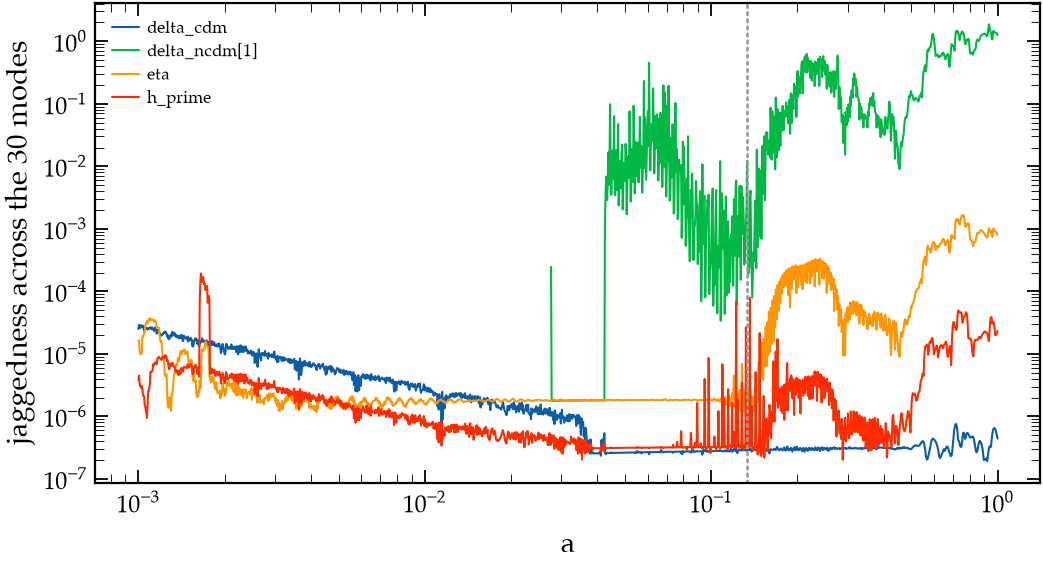

In [2]:
LNA = np.linspace(np.log(1e-3), 0.0, 1500)


def on_grid(pt, key):
    a = np.asarray(pt['a'])
    keep = np.append(np.diff(a) > 0, True)           # CLASS repeats rows at approximation switches
    return np.interp(LNA, np.log(a[keep]), np.asarray(pt[key])[keep])


fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)
for q in ('delta_cdm', 'delta_ncdm[1]', 'eta', 'h_prime'):
    M = np.array([on_grid(pt, q) for pt in base['perts']])
    res = np.array([detrend(K_DENSE, M[:, j]) for j in range(M.shape[1])]).T
    jag = np.max(np.abs(res), axis=0)/(np.sqrt(np.mean(M**2, axis=0)) + 1e-300)
    ax.semilogy(np.exp(LNA), jag, lw=1, label=q)
ax.axvline(A_T, color='0.6', ls=':')
ax.set_xscale('log')
ax.set_xlabel('a')
ax.set_ylabel('jaggedness across the 30 modes')
ax.legend(fontsize=8)
plt.show()

## 2. Not the momentum grid

In [3]:
for n_q in (51, 201, 801, 1601):
    o = base if n_q == 201 else run(n_q)
    r = detrend(K_DENSE, np.log(o['pk']))
    d = np.array([pt['delta_ncdm[1]'][-1]/pt['delta_cdm'][-1] for pt in o['perts']])
    print('{:>5d} bins: ln P rms {:.2e}, max {:.2e};  δ_daughter/δ_cdm today = {:.4f} ± {:.4f}  ({:.0f} s)'.format(
        n_q, np.sqrt(np.mean(r**2)), np.abs(r).max(), d.mean(), d.std(), o['sec']))

   51 bins: ln P rms 1.48e-03, max 3.32e-03;  δ_daughter/δ_cdm today = -0.0094 ± 0.0124  (4 s)
  201 bins: ln P rms 1.56e-03, max 3.40e-03;  δ_daughter/δ_cdm today = -0.0094 ± 0.0127  (18 s)
  801 bins: ln P rms 1.56e-03, max 3.40e-03;  δ_daughter/δ_cdm today = -0.0094 ± 0.0127  (86 s)


 1601 bins: ln P rms 1.56e-03, max 3.40e-03;  δ_daughter/δ_cdm today = -0.0094 ± 0.0127  (208 s)


## 3. Resolved in k

30 modes packed into k ∈ [0.1000, 0.1015] (spacing 5·10⁻⁵/Mpc). A sine plus a linear trend is fitted to
δ_daughter/δ_cdm and to ln P; smoothness is the rms of the second difference over the rms of the
detrended signal (~0.1 for a well-sampled sinusoid, ≳ 2 for scatter).

δ_daughter/δ_cdm  smoothness 0.07, period 1.30e-03/Mpc (D = 4828 Mpc), sine explains 100%
ln P              smoothness 0.07, period 1.31e-03/Mpc (D = 4804 Mpc), sine explains 100%


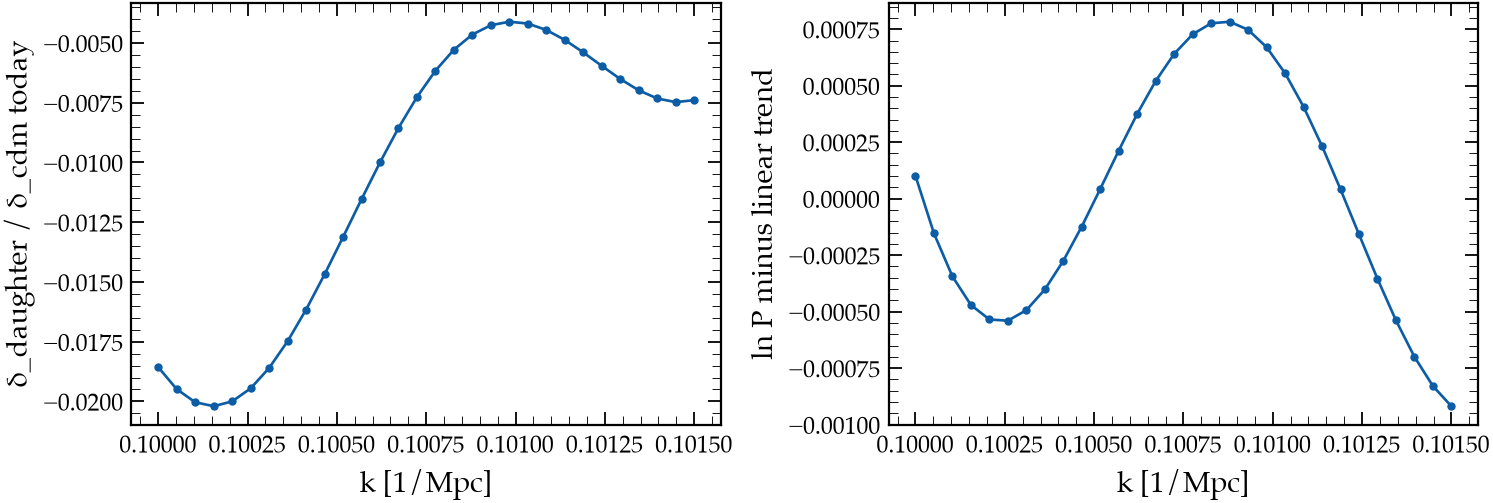

In [4]:
K_FINE = np.linspace(0.1000, 0.1015, 30)
fine = run(201, K_FINE)
ratio = np.array([pt['delta_ncdm[1]'][-1]/pt['delta_cdm'][-1] for pt in fine['perts']])
lnp = np.log(fine['pk'])


def sine_fit(y):
    """Best period (1/Mpc) of sine + linear trend, and the share of variance it explains."""
    x = K_FINE - K_FINE.mean()
    lin = y - np.polyval(np.polyfit(x, y, 1), x)
    best = (np.nan, -np.inf)
    for period in np.geomspace(1.5e-4, 3e-3, 600):
        w = 2*np.pi/period
        A = np.column_stack([np.ones_like(x), x, np.sin(w*x), np.cos(w*x)])
        coef = np.linalg.lstsq(A, y, rcond=None)[0]
        r2 = 1 - np.sum((y - A @ coef)**2)/np.sum(lin**2)
        best = max(best, (period, r2), key=lambda b: b[1])
    return best


for name, y in (('δ_daughter/δ_cdm', ratio), ('ln P', lnp)):
    period, r2 = sine_fit(y)
    smooth = np.std(np.diff(y, 2))/np.std(detrend(K_FINE, y, 1))
    print('{:<17} smoothness {:.2f}, period {:.2e}/Mpc (D = {:.0f} Mpc), sine explains {:.0%}'.format(
        name, smooth, period, 2*np.pi/period, r2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].plot(K_FINE, ratio, 'o-', ms=3)
axes[0].set_ylabel('δ_daughter / δ_cdm today')
axes[1].plot(K_FINE, detrend(K_FINE, lnp, 1), 'o-', ms=3)
axes[1].set_ylabel('ln P minus linear trend')
for ax in axes:
    ax.set_xlabel('k [1/Mpc]')
plt.show()